## **CSCN8020 – Assignment 3**  
### **Deep Q-Network (DQN) on Pong**  

**Student Name:** Jose George  
**Student ID:** 9082825  
**Course:** CSCN8020 – Reinforcement Learning Programming  

---

### **Overview**  

This notebook implements a **Deep Q-Network (DQN)** agent for the **Atari Pong** environment using image-based input and an object-oriented Python architecture.  

While the assignment specifies `PongDeterministic-v4`, the current Gymnasium + ALE environment uses the following equivalent configuration:  

- **Environment:** `ALE/Pong-v5`  
- **frameskip:** `4`  
- **repeat_action_probability:** `0.0`  
- **full_action_space:** `False`  

This setup replicates the intended deterministic environment behavior using updated APIs from Gymnasium and ALE.  

---

### **Requirements Covered**  

This notebook satisfies the following assignment criteria:  

- Implementation of **Deep Q-Learning** on Pong  
- **Object-oriented** Python code design  
- Single **Jupyter notebook** integrating Markdown and executable code  
- **Stacked 4-frame** state representation  
- **Episode-wise score** reporting  
- **Average cumulative reward** computed over the last 5 episodes  
- **Experimental comparisons:**
  - Batch Size: `8` vs `16`  
  - Target Network Update Frequency: every `3` vs `10` episodes  

---

### **Notebook Structure**  

The notebook is organized into sequential, purpose-driven sections following an experimental reinforcement learning workflow:  

**Setup → Preprocessing → Model Components → Debug Run → Duration Experiments → Hyperparameter Experiments → Extended Demo Run → Final Demo**  

This structure demonstrates an iterative development and testing process — beginning with environment validation (debug run), progressing through controlled experimentation, and culminating in a refined evaluation and demonstration phase.  

### **1. Imports and Setup**

This section imports all required libraries, registers the Atari environments, sets random seeds, and prepares the PyTorch device.

In [1]:
# Standard library imports
import os
import random
from collections import deque, namedtuple
from pathlib import Path

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
import ale_py

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Register ALE environments with Gymnasium
gym.register_envs(ale_py)

# Import the provided helper file
import assignment3_utils as utils

# -------------------------------
# Reproducibility
# -------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set CUDA seed as well when GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------------
# Device setup
# -------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Optional reproducibility settings for CUDA
# deterministic=True improves reproducibility
# benchmark=False avoids non-deterministic algorithm selection
if DEVICE.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("GPU name:", torch.cuda.get_device_name(0))

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Using device: cuda
GPU name: NVIDIA GeForce RTX 5060 Laptop GPU
Torch version: 2.11.0+cu128
CUDA available: True


#### **Environment Setup & Reproducibility**

In this section, all required libraries are initialized and the experimental environment is configured for training a Deep Q-Network (DQN) agent.

To ensure reproducibility, a fixed random seed (SEED = 42) is applied consistently across:
- Python's random module  
- NumPy  
- PyTorch (CPU and CUDA, if available)  

This helps maintain consistent and comparable results across runs, which is important for reliable evaluation in reinforcement learning experiments.

**GPU Acceleration**

The system automatically detects and utilizes a GPU if available; otherwise, it falls back to CPU execution.

Using GPU acceleration significantly improves training performance, especially for deep neural networks used in reinforcement learning.

Additional CUDA settings are configured (when GPU is available) to enhance reproducibility:
- deterministic = True ensures consistent computation results  
- benchmark = False avoids non-deterministic optimizations  

**Framework & Library Setup**

The implementation uses the following key technologies:

- **Gymnasium + ALE (Arcade Learning Environment)**  
  Provides Atari environments for reinforcement learning tasks  

- **PyTorch**  
  Used to build and train the Deep Q-Network  

- **Matplotlib**  
  Used for visualization and analysis of training performance  

The ALE environments are explicitly registered using:

```python
gym.register_envs(ale_py)

### **2. Hyperparameters**

The default values below follow the assignment instructions wherever specified.

In [2]:
# -------------------------------
# Environment configuration
# -------------------------------
ENV_NAME = "ALE/Pong-v5"

# Deterministic-style equivalent of old PongDeterministic-v4
ENV_KWARGS = {
    "render_mode": None,
    "frameskip": 4,
    "repeat_action_probability": 0.0,
    "full_action_space": False
}

# -------------------------------
# State preprocessing configuration
# -------------------------------
STACK_SIZE = 4
IMAGE_HEIGHT = 84
IMAGE_WIDTH = 80
STATE_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH)

# -------------------------------
# Assignment hyperparameters
# -------------------------------
GAMMA = 0.95
BATCH_SIZE = 8
TARGET_UPDATE_EPISODES = 10
EPSILON_START = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.05

# -------------------------------
# Additional training parameters
# -------------------------------
LEARNING_RATE = 1e-4
MEMORY_SIZE = 50000
MIN_REPLAY_SIZE = 1000
NUM_EPISODES_DEBUG = 5
MAX_STEPS_PER_EPISODE = 10000
TRAIN_EVERY = 1

# Output folder for saved plots/results
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Environment:", ENV_NAME)
print("State shape:", STATE_SHAPE)
print("Stack size:", STACK_SIZE)

Environment: ALE/Pong-v5
State shape: (84, 80)
Stack size: 4


#### **Environment & Hyperparameters**

We configure the Atari environment **ALE/Pong-v5** with deterministic-style settings to ensure stable and consistent training.

Key environment settings:
- frameskip = 4 → reduces computational load  
- repeat_action_probability = 0.0 → removes stochasticity  
- full_action_space = False → uses a reduced action set  

**State Representation**

Each state is preprocessed into:
- An **84 × 80 grayscale image**  
- A **stack of 4 consecutive frames**  

This representation captures motion information while reducing input dimensionality, making learning more efficient.

**Baseline Hyperparameters**

The following values are used as **default assignment settings before experimentation**:

- GAMMA = 0.95 → discount factor for future rewards  
- BATCH_SIZE = 8 → number of samples per training step  
- TARGET_UPDATE_EPISODES = 10 → frequency of target network updates  

**Epsilon-Greedy Exploration Strategy**

- Start: 1.0 → full exploration  
- Decay: 0.995 → gradual shift toward exploitation  
- Minimum: 0.05 → ensures continued exploration  

**Training Configuration**

- Learning rate: 1e-4 
- Replay memory size: 50000
- Minimum replay size: 1000 
- Maximum steps per episode: 10000 

A short debug run (`NUM_EPISODES_DEBUG = 5`) is used initially to verify correctness before running longer experiments.

**Setup Verification**

The following outputs confirm correct configuration:

- Environment: ALE/Pong-v5  
- State shape: (84, 80)  
- Stack size: 4  

This verifies that preprocessing and environment setup are correctly initialized and ready for training.

### **3. Environment Check**

This confirms that the Pong environment loads correctly in the current setup.

In [3]:
# Create the environment once to inspect its properties
env = gym.make(ENV_NAME, **ENV_KWARGS)

# Reset the environment and inspect the raw observation
obs, info = env.reset(seed=SEED)

print("Raw observation shape:", obs.shape)
print("Action space size:", env.action_space.n)
print("Observation dtype:", obs.dtype)

env.close()

Raw observation shape: (210, 160, 3)
Action space size: 6
Observation dtype: uint8


#### **Interpretation**

**Environment Inspection**

The environment is initialized to examine its raw observation format and action space before applying preprocessing.

**Observation Details**

- Shape: (210, 160, 3)  
- Data type: uint8  

This indicates:
- RGB image input  
- High-resolution frames  
- Pixel values in the range [0, 255]  

Since this representation is computationally expensive and not suitable for direct learning, preprocessing (grayscale conversion, resizing, and frame stacking) is required before training.

**Action Space**

- Total actions: 6  

This represents the available controls in the Pong environment. In practice, only a subset of these actions is relevant for effective gameplay, but the full action space is preserved for generality.

**Conclusion**

This step confirms that:
- the environment is correctly initialized  
- observations are in raw image format  
- preprocessing is necessary before training begins  

### **4. Frame Preprocessing Demonstration**

The provided assignment3_utils.py file is used for frame preprocessing.
This includes cropping, downsampling, grayscale conversion, and normalization.

Raw frame shape: (210, 160, 3)
Processed frame shape: (1, 84, 80, 1)


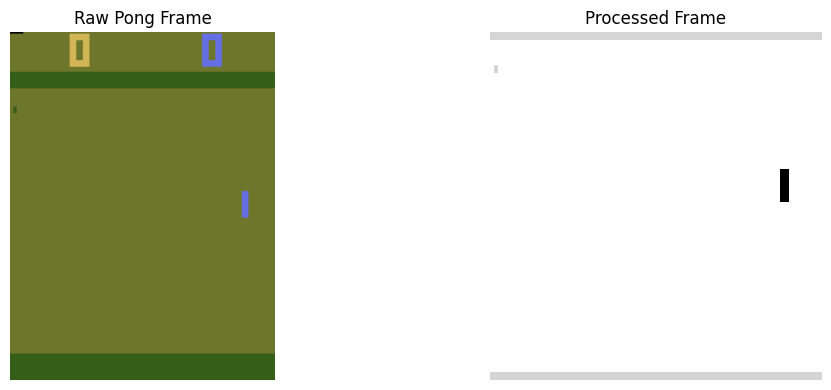

In [4]:
# Recreate the environment to get a sample frame
env = gym.make(ENV_NAME, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)

# Process the raw frame using the provided helper function
processed = utils.process_frame(obs, STATE_SHAPE)

print("Raw frame shape:", obs.shape)
print("Processed frame shape:", processed.shape)

# Display raw and processed images
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(obs)
plt.title("Raw Pong Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed[0, :, :, 0], cmap="gray")
plt.title("Processed Frame")
plt.axis("off")

plt.tight_layout()
plt.show()

env.close()

#### **Interpretation**

**State Preprocessing**

A sample frame from the Pong environment is processed to prepare it for input into the Deep Q-Network (DQN).

**Processing Steps**

The raw frame undergoes the following transformations:
- Conversion from RGB to grayscale  
- Resizing from (210, 160) to (84, 80)  
- Normalization and reshaping for model input  

**Shape Transformation**

- Raw frame: (210, 160, 3)  
- Processed frame: (1, 84, 80, 1)  

This transformation significantly reduces input dimensionality while preserving important visual features such as paddle positions and ball movement.

**Importance of Preprocessing**

Preprocessing is essential because it:
- Reduces computational complexity  
- Improves training efficiency  
- Removes unnecessary color information  
- Helps the model focus on relevant game dynamics  

**Conclusion**

The comparison between raw and processed frames confirms that preprocessing is correctly applied and that the resulting state representation is suitable for frame stacking and input into the neural network.

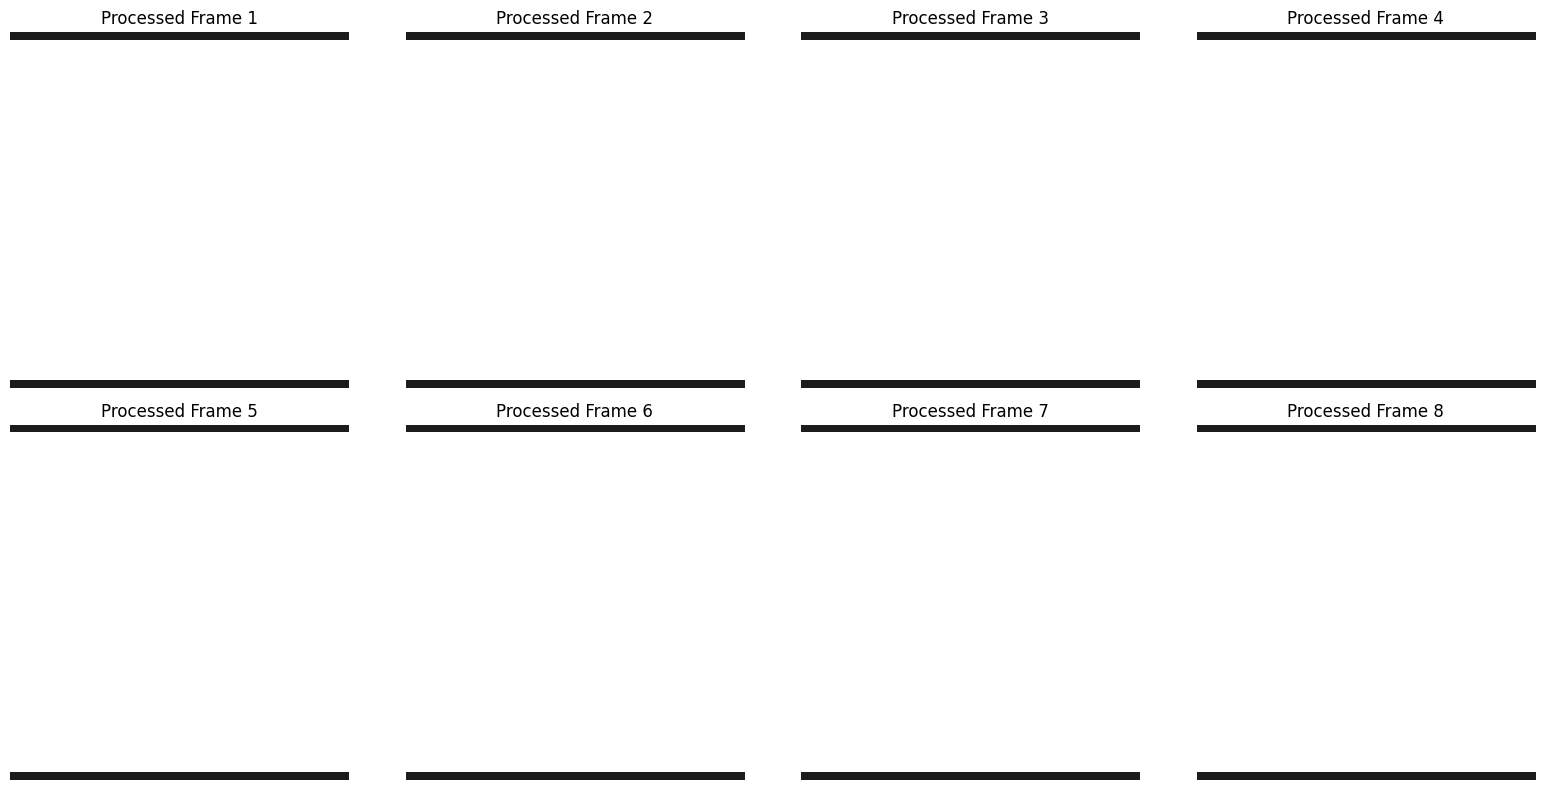

In [5]:
# Visualize several consecutive processed frames after starting gameplay
# using contrast scaling for better human interpretation only

env = gym.make(ENV_NAME, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)

frames = []

# Start the Pong rally with FIRE
fire_action = 1
obs, reward, terminated, truncated, info = env.step(fire_action)

for _ in range(8):
    # Process the current frame using the training pipeline
    processed = utils.process_frame(obs, STATE_SHAPE)
    frames.append(processed[0, :, :, 0])

    # Use a random action after the serve
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    # If episode ends, reset and serve again
    if terminated or truncated:
        obs, info = env.reset()
        obs, reward, terminated, truncated, info = env.step(fire_action)

env.close()

# Plot processed frames with visualization-only contrast enhancement
plt.figure(figsize=(16, 8))
for i, frame in enumerate(frames):
    plt.subplot(2, 4, i + 1)

    # Contrast scaling only for display; does not affect training data
    plt.imshow(frame, cmap="gray", vmin=-0.2, vmax=0.2)

    plt.title(f"Processed Frame {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Interpretation**

**Temporal Frame Visualization**

To understand how the agent captures motion, multiple consecutive processed frames are visualized after gameplay begins.

**Key Observations**

- Each frame shows the paddle and ball in slightly different positions  
- Changes across frames capture motion over time  
- The background remains largely static, while key objects (paddle and ball) shift  

**Importance of Temporal Information**

A single frame does not provide sufficient information about movement. By observing consecutive frames:

- The agent can infer the direction and speed of the ball  
- Temporal patterns improve decision-making  
- This supports the use of frame stacking (STACK_SIZE = 4) in the DQN input  

**Visualization Note**

Contrast scaling (vmin, vmax) is applied only for visualization purposes to enhance visibility of key features.

- This does not affect the training data  
- The model receives the original processed frames without modification  

**Conclusion**

These visualizations confirm that:
- preprocessing preserves essential gameplay features  
- temporal variation between frames is clearly observable  
- the environment provides sufficient information for learning dynamic behavior  

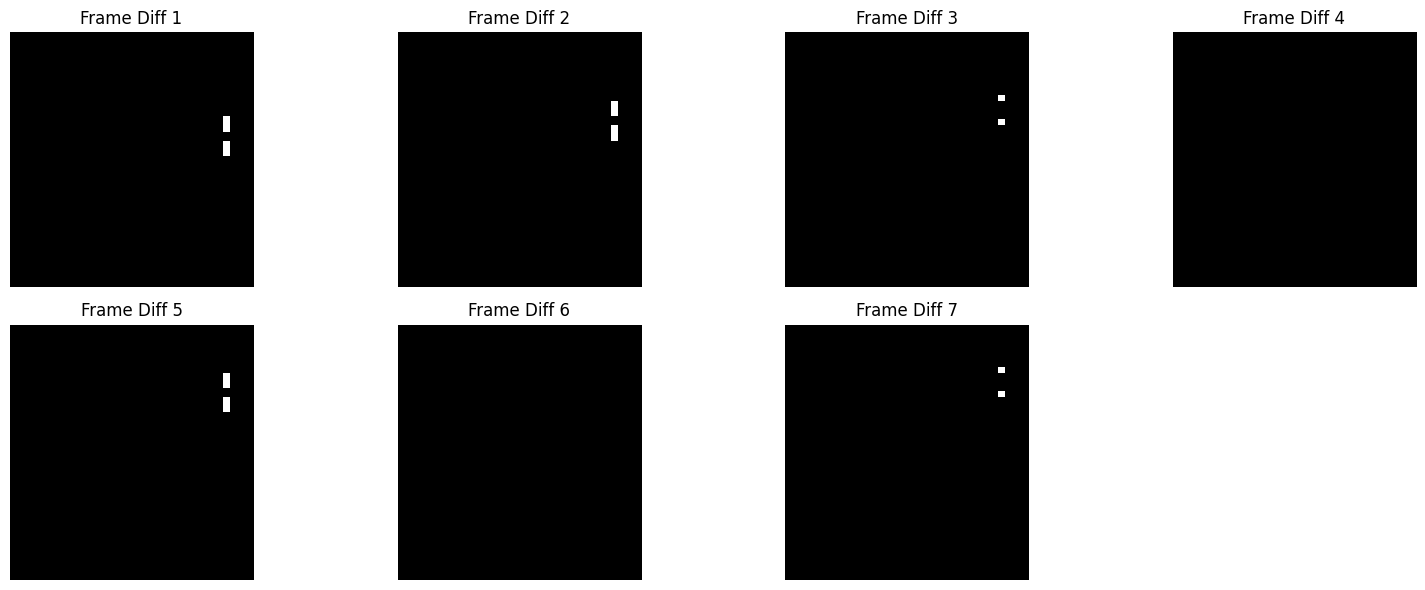

In [6]:
# Visualize motion between consecutive processed frames
env = gym.make(ENV_NAME, **ENV_KWARGS)
obs, info = env.reset(seed=SEED)

frames = []

# Start gameplay with FIRE
fire_action = 1
obs, reward, terminated, truncated, info = env.step(fire_action)

for _ in range(8):
    processed = utils.process_frame(obs, STATE_SHAPE)
    frames.append(processed[0, :, :, 0])

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        obs, info = env.reset()
        obs, reward, terminated, truncated, info = env.step(fire_action)

env.close()

# Compute absolute differences between consecutive frames
diffs = []
for i in range(len(frames) - 1):
    diffs.append(np.abs(frames[i + 1] - frames[i]))

plt.figure(figsize=(16, 6))
for i, diff in enumerate(diffs):
    plt.subplot(2, 4, i + 1)
    plt.imshow(diff, cmap="gray")
    plt.title(f"Frame Diff {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### **Interpretation**

**Motion Representation via Frame Differences**

To further analyze how motion is captured, absolute differences between consecutive processed frames are visualized.

**Key Observations**

- Regions of change are clearly highlighted in the frame difference images  
- The paddle and ball movements appear as bright regions  
- Static background elements are effectively removed  

**Understanding Motion Capture**

Although the ball is not always clearly visible in individual processed frames due to its small size and downsampling, its motion becomes evident through frame differences.

This demonstrates that:
- Temporal changes between frames encode movement information  
- Even subtle object motion can be detected through differences  
- Spatial detail may be reduced, but temporal information is preserved  

**Importance for Reinforcement Learning**

These observations are critical because:

- The agent relies on **changes over time**, not just single frames  
- Motion cues help infer direction and velocity of the ball  
- This validates the use of frame stacking (STACK_SIZE = 4) in Deep Q-Networks  

**Conclusion**

The preprocessing pipeline successfully:
- Reduces visual complexity by removing irrelevant background details  
- Preserves essential motion information through temporal differences  
- Provides sufficient signal for learning dynamic gameplay behavior  

This confirms that the state representation is well-suited for effective policy learning.

### **5. Frame Stacking Helper**

The agent uses 4 stacked frames as the state so that motion information can be learned from consecutive observations.

In [7]:
def stack_frames(frame_stack, new_frame, stack_size=STACK_SIZE):
    """
    Stack processed frames along the channel dimension.

    Parameters:
        frame_stack: deque storing recent processed frames
        new_frame: processed frame with shape (84, 80, 1)
        stack_size: number of frames to stack

    Returns:
        stacked_state: shape (84, 80, 4)
        frame_stack: updated deque
    """
    # At the beginning of an episode, duplicate the first frame
    if len(frame_stack) == 0:
        for _ in range(stack_size):
            frame_stack.append(new_frame)
    else:
        frame_stack.append(new_frame)

    # Concatenate frames along the last dimension
    stacked_state = np.concatenate(frame_stack, axis=2)
    return stacked_state, frame_stack

#### **Interpretation**

**Frame Stacking**

To capture motion information, multiple consecutive frames are combined into a single state representation.

**How It Works**

- A deque stores the most recent processed frames  
- At the start of an episode, the first frame is duplicated to initialize the stack  
- New frames are appended while older frames are automatically discarded  

The final state is created by concatenating frames along the channel dimension:
- Single frame: (84, 80, 1)  
- Stacked state: (84, 80, 4)  

**Why Frame Stacking is Important**

A single frame does not provide sufficient information about movement. By stacking frames:

- The agent can infer the direction and velocity of the ball  
- Temporal context improves decision-making  
- The state representation better approximates a Markov Decision Process (MDP)  

**Key Insight**

Frame stacking enables the model to learn from temporal differences across frames, which is essential in dynamic environments like Pong.

Without stacking, the agent would lack motion information and struggle to learn an effective policy.

### **6. Replay Buffer**

Experience replay stores transitions and samples random mini-batches for stable training.

In [8]:
# Transition tuple used for replay memory
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    """Replay memory for storing and sampling transitions."""

    def __init__(self, capacity):
        # Maximum number of stored transitions
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # Store one transition
        self.memory.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Randomly sample a mini-batch
        batch = random.sample(self.memory, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        # Current number of stored transitions
        return len(self.memory)

#### **Interpretation**

**Experience Replay Buffer**

The replay buffer is a key component of Deep Q-Networks (DQN) that stores past experiences and allows the agent to learn from randomly sampled mini-batches rather than sequential data.

**How It Works**

Each interaction with the environment is stored as a transition:

- (state, action, reward, next_state, done)

In this implementation:

- A deque is used with a fixed maximum capacity  
- push() stores new transitions  
- sample() randomly selects a batch of experiences  
- When capacity is exceeded, older transitions are automatically removed  

The sampled batch is returned in a structured format using namedtuple, making it easy to unpack during training.

**Why Experience Replay is Important**

- Breaks correlation between consecutive experiences  
- Stabilizes learning by smoothing the data distribution  
- Improves sample efficiency by reusing past transitions  
- Prevents the model from overfitting to recent experiences  

Random sampling ensures that updates are based on a diverse set of past interactions rather than highly correlated sequences.

**Connection to DQN Training**

During training:

- The agent collects transitions at each step  
- Once enough samples are available, mini-batches are drawn from the replay buffer  
- These batches are used to compute the loss and update the Q-network  

This process is essential for stable gradient updates in deep reinforcement learning.

**Key Insight**

Without experience replay, the model would learn from sequential data, leading to unstable updates and poor convergence.

The replay buffer enables more reliable and efficient learning by approximating independent and identically distributed (i.i.d.) training data.

### **7. Deep Q-Network**

A convolutional neural network is used because the state is image-based.

In [9]:
class DQN(nn.Module):
    """CNN-based Q-network for Atari Pong."""

    def __init__(self, input_channels=4, num_actions=6):
        super(DQN, self).__init__()

        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)

        # Dynamically compute flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, IMAGE_HEIGHT, IMAGE_WIDTH)
            conv_out = self._forward_conv(dummy)
            self.flattened_size = conv_out.view(1, -1).size(1)

        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def _forward_conv(self, x):
        # Pass input through convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return x

    def forward(self, x):
        # Forward pass through the whole network
        x = self._forward_conv(x)
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

#### **Interpretation**

**Deep Q-Network (DQN)**

A Convolutional Neural Network (CNN) is used to approximate the Q-value function because the agent receives high-dimensional image inputs (stacked frames).

Instead of using a tabular representation, the network learns a function:

Q(s, a; θ)

which maps a state to Q-values for all possible actions.

**Network Architecture**

The model consists of two main components:

**Convolutional Layers (Feature Extraction)**

- Extract spatial and motion-related features from stacked frames  
- Learn patterns such as paddle position, ball trajectory, and velocity  

Layers:
- Conv1 → 32 filters (8×8, stride 4)  
- Conv2 → 64 filters (4×4, stride 2)  
- Conv3 → 64 filters (3×3, stride 1)  

These layers progressively reduce spatial dimensions while increasing feature depth.

**Fully Connected Layers (Decision Making)**

- Flatten extracted features into a vector  
- Learn action-value relationships  

Layers:
- FC1 → 512 units with ReLU activation  
- FC2 → outputs Q-values for each action (6 actions)  

**Forward Pass**

1. Input: stacked frames with shape (4, 84, 80)  
2. Pass through convolutional layers  
3. Flatten feature maps  
4. Pass through fully connected layers  
5. Output: Q-values for all actions  

**Output Interpretation**

- The network outputs a vector of Q-values  
- Each value represents the expected future reward for taking that action  
- The agent selects the action with the highest Q-value  

**Why CNN is Suitable for Pong**

- Captures spatial relationships (ball vs paddle position)  
- Learns motion patterns from stacked frames  
- Reduces need for manual feature engineering  

**Connection to DQN Learning**

During training:

- The network predicts Q(s, a)  
- These predictions are compared against target Q-values  
- The difference is minimized using gradient descent  

This allows the model to approximate the optimal action-value function over time.

**Key Insight**

The DQN replaces the traditional Q-table with a deep neural network, enabling learning directly from raw pixel inputs and making it scalable to complex environments like Atari Pong.

### **8. DQN Agent**

This class handles action selection, learning, target network synchronization, and epsilon decay.

In [10]:
class DQNAgent:
    """DQN agent with policy network, target network, and epsilon-greedy policy."""

    def __init__(
        self,
        num_actions,
        gamma=GAMMA,
        lr=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        epsilon_start=EPSILON_START,
        epsilon_decay=EPSILON_DECAY,
        epsilon_min=EPSILON_MIN
    ):
        self.num_actions = num_actions
        self.gamma = gamma
        self.batch_size = batch_size

        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Online network used for learning
        self.policy_net = DQN(input_channels=STACK_SIZE, num_actions=num_actions).to(DEVICE)

        # Target network used for stable targets
        self.target_net = DQN(input_channels=STACK_SIZE, num_actions=num_actions).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Adam optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

    def select_action(self, state):
        """Choose an action using epsilon-greedy exploration."""
        # Random action for exploration
        if random.random() < self.epsilon:
            return random.randrange(self.num_actions)

        # Greedy action from the policy network
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE)
        state_tensor = state_tensor.permute(2, 0, 1).unsqueeze(0)

        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
            action = torch.argmax(q_values, dim=1).item()

        return int(action)

    def decay_epsilon(self):
        """Decay epsilon after each episode."""
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)

    def train_step(self, replay_buffer):
        """Run one training step using a sampled mini-batch."""
        # Do not train until enough samples exist
        if len(replay_buffer) < self.batch_size:
            return None

        # Sample a mini-batch
        batch = replay_buffer.sample(self.batch_size)

        # Convert batch components to tensors
        states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=DEVICE).permute(0, 3, 1, 2)
        actions = torch.tensor(batch.action, dtype=torch.long, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=DEVICE).permute(0, 3, 1, 2)
        dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        # Q-values predicted by the policy network
        current_q = self.policy_net(states).gather(1, actions)

        # Stable target values from the target network
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + (1 - dones) * self.gamma * max_next_q

        # Mean squared error loss
        loss = F.mse_loss(current_q, target_q)

        # Standard optimization step
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping for better stability
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)

        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Copy policy network weights into target network."""
        self.target_net.load_state_dict(self.policy_net.state_dict())

### **Interpretation**

**DQN Agent**

The DQN agent is the core component that brings together action selection, learning, and stability mechanisms. It uses two neural networks and an experience replay buffer to learn an optimal policy.

**Core Components**

- **Policy Network (Online Network)**  
  Learns and predicts Q-values for the current state  

- **Target Network**  
  Provides stable target Q-values  
  Periodically updated from the policy network  

- **Optimizer (Adam)**  
  Updates the policy network weights using gradient descent  

**Action Selection (Epsilon-Greedy Policy)**

The agent balances exploration and exploitation:

- With probability ε → select a random action (exploration)  
- Otherwise → select the best action using the policy network  

Epsilon decays over time:
- Starts high → encourages exploration  
- Gradually decreases → favors exploitation  

**Training Process**

During each training step:

1. Sample a mini-batch from the replay buffer  
2. Compute current Q-values:
   Q(s, a) from the policy network  
3. Compute target Q-values using the target network:
   
   target = r + (1 − done) · γ · max Q(next_state, a)

4. Compute loss using Mean Squared Error (MSE)  
5. Perform backpropagation and update network weights  

**Connection to Bellman Equation**

The agent learns by minimizing the difference between:

- Current estimate: Q(s, a)  
- Target estimate: r + γ max Q(s′, a′)  

This is a neural approximation of the Bellman optimality equation.

**Stability Mechanisms**

- **Target Network** → prevents rapidly shifting targets  
- **Experience Replay** → reduces correlation in training data  
- **Gradient Clipping** → prevents exploding gradients  

These mechanisms are essential for stable deep reinforcement learning.

**How This Matches the Implementation**

- select_action() → implements epsilon-greedy policy  
- train_step() → performs batch learning using replay buffer  
- update_target_network() → synchronizes target network  
- decay_epsilon() → controls exploration over time  

**Key Insight**

The DQN agent learns by iteratively reducing the error between predicted and target Q-values.

By combining neural networks, replay memory, and target stabilization, the agent can learn effective policies from high-dimensional visual input in environments like Pong.

### **9. Trainer Class**

This class manages:
- environment interaction
- preprocessing
- frame stacking
- replay buffer warmup
- episode training loop
- metrics collection

In [11]:
class PongTrainer:
    """Training manager for DQN on Pong."""

    def __init__(
        self,
        env_name=ENV_NAME,
        env_kwargs=ENV_KWARGS,
        batch_size=BATCH_SIZE,
        target_update_episodes=TARGET_UPDATE_EPISODES,
        num_episodes=NUM_EPISODES_DEBUG
    ):
        self.env_name = env_name
        self.env_kwargs = env_kwargs
        self.batch_size = batch_size
        self.target_update_episodes = target_update_episodes
        self.num_episodes = num_episodes

        # Create the environment
        self.env = gym.make(self.env_name, **self.env_kwargs)
        self.num_actions = self.env.action_space.n

        # Create agent and replay buffer
        self.agent = DQNAgent(num_actions=self.num_actions, batch_size=batch_size)
        self.replay_buffer = ReplayBuffer(MEMORY_SIZE)

        # Training metrics
        self.episode_scores = []
        self.last5_avg_rewards = []
        self.loss_history = []
        self.episode_steps = []

    def preprocess_observation(self, obs):
        """Convert raw RGB frame into processed frame with shape (84, 80, 1)."""
        return utils.process_frame(obs, STATE_SHAPE)[0]

    def initialize_state(self, obs):
        """Build the initial stacked state at the start of an episode."""
        frame_stack = deque(maxlen=STACK_SIZE)
        processed_frame = self.preprocess_observation(obs)
        state, frame_stack = stack_frames(frame_stack, processed_frame)
        return state, frame_stack

    def warmup_replay_buffer(self):
        """Fill replay memory with random experience before learning starts."""
        print("Warming up replay buffer...")

        obs, info = self.env.reset(seed=SEED)
        state, frame_stack = self.initialize_state(obs)

        while len(self.replay_buffer) < MIN_REPLAY_SIZE:
            # Random exploratory action
            action = self.env.action_space.sample()

            # Step the environment
            next_obs, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated

            # Transform reward using provided helper
            transformed_reward = utils.transform_reward(reward)

            # Build next stacked state
            next_frame = self.preprocess_observation(next_obs)
            next_state, frame_stack = stack_frames(frame_stack, next_frame)

            # Store the transition
            self.replay_buffer.push(state, action, transformed_reward, next_state, done)

            # Move to the next state
            state = next_state

            # Reset if episode ends during warmup
            if done:
                obs, info = self.env.reset()
                state, frame_stack = self.initialize_state(obs)

        print(f"Replay buffer size after warmup: {len(self.replay_buffer)}")

    def train(self):
        """Run full training."""
        self.warmup_replay_buffer()

        total_steps = 0

        for episode in range(1, self.num_episodes + 1):
            # Reset environment at start of episode
            obs, info = self.env.reset()
            state, frame_stack = self.initialize_state(obs)

            done = False
            episode_reward = 0.0
            step_count = 0

            while not done and step_count < MAX_STEPS_PER_EPISODE:
                # Select epsilon-greedy action
                action = self.agent.select_action(state)

                # Interact with environment
                next_obs, reward, terminated, truncated, info = self.env.step(action)
                done = terminated or truncated

                # Use transformed reward for learning
                transformed_reward = utils.transform_reward(reward)

                # Build next state
                next_frame = self.preprocess_observation(next_obs)
                next_state, frame_stack = stack_frames(frame_stack, next_frame)

                # Store transition
                self.replay_buffer.push(state, action, transformed_reward, next_state, done)

                # Learn every TRAIN_EVERY steps
                if total_steps % TRAIN_EVERY == 0:
                    loss = self.agent.train_step(self.replay_buffer)
                    if loss is not None:
                        self.loss_history.append(loss)

                # Update state
                state = next_state

                # Track original episode reward as score
                episode_reward += reward
                step_count += 1
                total_steps += 1

            # Store assignment metrics
            self.episode_scores.append(episode_reward)
            avg_last5 = np.mean(self.episode_scores[-5:])
            self.last5_avg_rewards.append(avg_last5)
            self.episode_steps.append(total_steps)

            # Update target network according to experiment setting
            if episode % self.target_update_episodes == 0:
                self.agent.update_target_network()

            # Decay epsilon after episode
            self.agent.decay_epsilon()

            print(
                f"Episode {episode:03d} | "
                f"Score: {episode_reward:6.2f} | "
                f"AvgLast5: {avg_last5:6.2f} | "
                f"Epsilon: {self.agent.epsilon:6.4f}"
            )

        self.env.close()

    def get_results(self):
        """Return training results in dictionary form."""
        return {
            "episode_scores": self.episode_scores,
            "last5_avg_rewards": self.last5_avg_rewards,
            "episode_steps": self.episode_steps,
            "loss_history": self.loss_history,
            "batch_size": self.batch_size,
            "target_update_episodes": self.target_update_episodes
        }

### **Interpretation**

**DQN Training Pipeline (Trainer Class)**

The PongTrainer class orchestrates the complete Deep Q-Learning pipeline, integrating environment interaction, preprocessing, experience replay, and model optimization into a structured training workflow.

**Overall Responsibility**

This class acts as the controller that connects all components:

- Environment (Gym Pong)  
- Preprocessing and frame stacking  
- Replay buffer management  
- DQN agent training  
- Metrics collection for analysis  

**Training Workflow (Per Episode)**

Each episode follows a structured loop:

1. Reset environment and initialize stacked state  
2. Select action using epsilon-greedy policy  
3. Execute action in the environment  
4. Preprocess next frame and update stacked state  
5. Store transition in replay buffer  
6. Perform learning step at fixed intervals  
7. Repeat until episode terminates or step limit is reached  

This loop ensures continuous interaction and learning from the environment.

**Replay Buffer Warmup Phase**

Before training begins, the replay buffer is pre-filled using random actions:

- Ensures sufficient and diverse experience  
- Avoids unstable learning from small sample sizes  
- Enables meaningful mini-batch updates from the start  

Training only begins after reaching a minimum replay size.

**Learning Strategy**

- **Reward Transformation** → stabilizes reward signals  
- **Step-based Training** → learning occurs every fixed number of steps  
- **Mini-batch Updates** → improves generalization and efficiency  

The agent updates its Q-values by sampling from past experiences rather than relying only on recent transitions.

**Target Network Updates**

- The target network is updated periodically (based on experiment settings)  
- This reduces instability caused by rapidly changing Q-value targets  

**Exploration Strategy**

- Epsilon decays after each episode  
- Early training → more exploration  
- Later training → more exploitation  

This ensures sufficient state-space coverage before convergence.

**Metrics Collection**

The trainer tracks key performance indicators:

- Episode rewards (scores)  
- Average reward over last 5 episodes  
- Training loss history  
- Total steps per episode  

These metrics are used for performance evaluation and comparison across experiments.

**Connection to Implementation**

- warmup_replay_buffer → fills memory before learning  
- train() → runs full training loop  
- initialize_state() → builds stacked state  
- preprocess_observation() → converts raw frames  
- get_results() → returns structured experiment results  

**Key Insight**

The Trainer class integrates all DQN components into a cohesive learning system.

By combining controlled exploration, replay-based learning, and periodic stabilization, the training process enables the agent to progressively improve its policy and achieve better performance in Pong over time.

### **10. Plotting Utilities**

These functions are used to visualize the required assignment results.

In [12]:
def plot_training_metrics(results, title_suffix="Run"):
    """Plot score per episode and average reward of the last 5 episodes."""
    scores = results["episode_scores"]
    avg_last5 = results["last5_avg_rewards"]
    steps = results["episode_steps"]

    plt.figure(figsize=(12, 5))
    plt.plot(steps, scores)
    plt.title(f"Score per Episode - {title_suffix}")
    plt.xlabel("Training Steps")
    plt.ylabel("Episode Score")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(steps, avg_last5)
    plt.title(f"Average Cumulative Reward of Last 5 Episodes - {title_suffix}")
    plt.xlabel("Training Steps")
    plt.ylabel("Average Reward")
    plt.grid(True)
    plt.show()


def compare_runs(results_list, metric_key, labels, title, ylabel):
    """Compare a selected metric across multiple runs."""
    plt.figure(figsize=(12, 5))

    for results, label in zip(results_list, labels):
        x = results["episode_steps"]
        y = results[metric_key]
        plt.plot(x, y, label=label)

    plt.title(title)
    plt.xlabel("Training Steps")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

### **Interpretation**

**Training Visualization and Evaluation**

These plotting utilities are used to analyze the learning behavior of the DQN agent and support comparison across different experimental configurations.

**Metrics Visualized**

1. **Score per Episode**

- Represents the total reward obtained in each episode  
- Provides a direct measure of agent performance  
- Helps identify variability and instability during training  

2. **Average Reward (Last 5 Episodes)**

- Smooths short-term fluctuations in rewards  
- Highlights overall learning trends  
- Provides a clearer indication of performance improvement over time  

**Why Training Steps are Used (X-axis)**

Instead of episode index, training steps are used:

- Reflects the true amount of interaction with the environment  
- Allows fair comparison across runs with different episode lengths  
- More accurately represents learning progression  

**Comparison Across Runs**

The compare_runs function enables side-by-side evaluation of multiple experiments:

- Compares different hyperparameters (e.g., batch size, target update frequency)  
- Helps identify which configuration leads to better learning performance  
- Supports evidence-based conclusions in the analysis section  

**Role in Reinforcement Learning Evaluation**

Visualization is critical in reinforcement learning because:

- Learning signals are noisy and non-deterministic  
- Performance cannot be judged from a single episode  
- Trends over time are more meaningful than isolated results  

**Key Insight**

By combining raw episode scores with smoothed averages and cross-run comparisons, these plots provide a comprehensive view of:

- learning stability  
- convergence behavior  
- relative performance across experiments  

This enables informed evaluation of the DQN agent and supports the conclusions drawn in subsequent analysis sections.

### **11. Default Training Run**

This first run uses the assignment default settings:
- batch size = 8
- target update = every 10 episodes
- gamma = 0.95
- epsilon start = 1.0
- epsilon decay = 0.995
- epsilon minimum = 0.05

In [13]:
# For first testing, use NUM_EPISODES_DEBUG
default_trainer = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_DEBUG
)

default_trainer.train()
default_results = default_trainer.get_results()

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9950
Episode 002 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9900
Episode 003 | Score: -21.00 | AvgLast5: -20.33 | Epsilon: 0.9851
Episode 004 | Score: -20.00 | AvgLast5: -20.25 | Epsilon: 0.9801
Episode 005 | Score: -21.00 | AvgLast5: -20.40 | Epsilon: 0.9752


### **Interpretation**

**Initial Debug Run (Pipeline Validation)**

A short training run is executed using a small number of episodes (NUM_EPISODES_DEBUG = 5) to validate that the entire DQN pipeline is functioning correctly before conducting longer experiments.

**What This Run Verifies**

This stage is not intended to evaluate performance, but to confirm that:

- Replay buffer warmup completes successfully  
- Environment interaction loop runs without errors  
- State preprocessing and frame stacking work correctly  
- The agent can select actions and update Q-values  
- Training steps execute without instability or crashes  

**Observations**

- Replay buffer is successfully filled to the minimum required size  
- Training loop executes correctly across all episodes  
- Episode scores remain negative, which is expected at this stage  
- Epsilon decays gradually, confirming proper exploration scheduling  

**Why Performance is Low**

Poor performance during this phase is expected because:

- The agent is primarily exploring (high epsilon)  
- The policy network is not yet trained  
- Pong provides sparse and delayed rewards  
- Learning requires many more interactions to improve  

**Role in Experimental Workflow**

This debug run represents the **exploration phase** of the experimentation process:

- Step 1 → Verify implementation correctness  
- Step 2 → Ensure stable execution  
- Step 3 → Proceed to longer training runs for meaningful evaluation  

**Key Insight**

Short runs are essential for debugging but are not suitable for evaluating reinforcement learning performance.

They ensure that the system is correctly implemented before investing computational time in larger experiments.

**Conclusion**

The debug run confirms that the DQN pipeline is correctly implemented and stable, allowing us to proceed to extended training experiments where meaningful learning behavior can be observed.

In [14]:
print(default_results.keys())

dict_keys(['episode_scores', 'last5_avg_rewards', 'episode_steps', 'loss_history', 'batch_size', 'target_update_episodes'])


### **Training Results Structure**

The training output is stored in a structured dictionary that captures all key metrics required for evaluation, visualization, and comparison across experiments.

**Available Metrics**

- **episode_scores** → total reward obtained per episode  
- **last5_avg_rewards** → moving average of rewards (last 5 episodes) for trend analysis  
- **episode_steps** → cumulative training steps corresponding to each episode  
- **loss_history** → loss values recorded during training updates  
- **batch_size** → mini-batch size used for the experiment  
- **target_update_episodes** → frequency of target network updates  

**Why This Structure is Important**

This standardized format enables:

- Consistent plotting of training performance  
- Direct comparison between different experimental configurations  
- Tracking both short-term variability and long-term learning trends  

Each experiment produces results in the same structure, making analysis systematic and reproducible.

**Connection to Visualization and Experiments**

- episode_scores → used in score-per-episode plots  
- last5_avg_rewards → used for smoothed performance curves  
- episode_steps → ensures fair comparison across runs  
- loss_history → helps analyze training stability  

These metrics directly feed into the plotting utilities defined earlier.

**Role in Experimental Evaluation**

By storing results in a structured dictionary:

- Multiple runs can be easily compared  
- Hyperparameter impact can be analyzed  
- Observations can be supported with quantitative evidence  

This is essential for drawing reliable conclusions in reinforcement learning experiments.

**Key Insight**

A well-structured results format is critical for reproducibility and analysis, allowing experiments to be compared objectively and ensuring that conclusions are based on consistent and interpretable metrics.

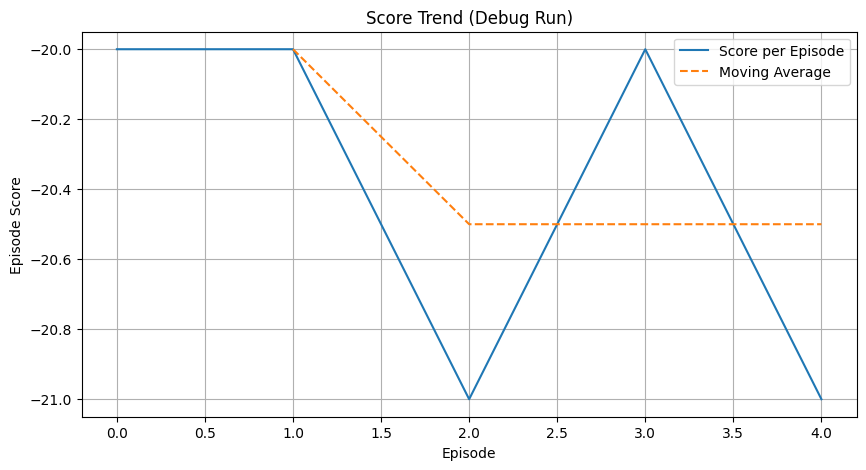

In [15]:
plt.figure(figsize=(10, 5))

scores = default_results["episode_scores"]

plt.plot(scores, label="Score per Episode")

window = 2
if len(scores) >= window:
    moving_avg = np.convolve(
        scores,
        np.ones(window) / window,
        mode="valid"
    )
    plt.plot(
        range(window - 1, len(scores)),
        moving_avg,
        label="Moving Average",
        linestyle="--"
    )

plt.title("Score Trend (Debug Run)")
plt.xlabel("Episode")
plt.ylabel("Episode Score")
plt.legend()
plt.grid(True)
plt.show()

### **Score Trend Analysis (Debug Run)**

The plot visualizes episode scores along with a moving average to examine short-term behavior during the initial debug run.

**Observations**

- Episode scores remain consistently negative (around -20 to -21)  
- There is minimal variation across episodes  
- The moving average closely follows the raw scores due to the short run length  
- No upward trend or improvement is observed  

**Interpretation of Learning Behavior**

This pattern indicates that the agent has not yet begun meaningful learning.

This is expected because:

- The agent is still in a high-exploration phase (epsilon ≈ 1)  
- Actions are largely random  
- The policy network is untrained  
- Pong has sparse and delayed rewards, making early progress slow  

**Limitations of This Plot**

- The number of episodes (5) is too small to observe learning trends  
- The moving average window is very short, providing limited smoothing  
- Performance cannot be meaningfully evaluated at this stage  

**Role of Moving Average**

- Reduces noise in longer training runs  
- Helps reveal trends when sufficient data is available  
- In this case, it provides little additional insight due to limited data  

**Key Insight**

This plot serves as a validation of pipeline execution rather than a performance evaluation.

It confirms that:

- Training is running correctly  
- Metrics are being recorded properly  
- Visualization tools are functioning as expected  

**Conclusion**

The debug run shows no learning progress, which is expected.

Meaningful evaluation requires longer training runs with significantly more episodes, which will be explored in the next sections.

### **12. Plot Default Training Results**

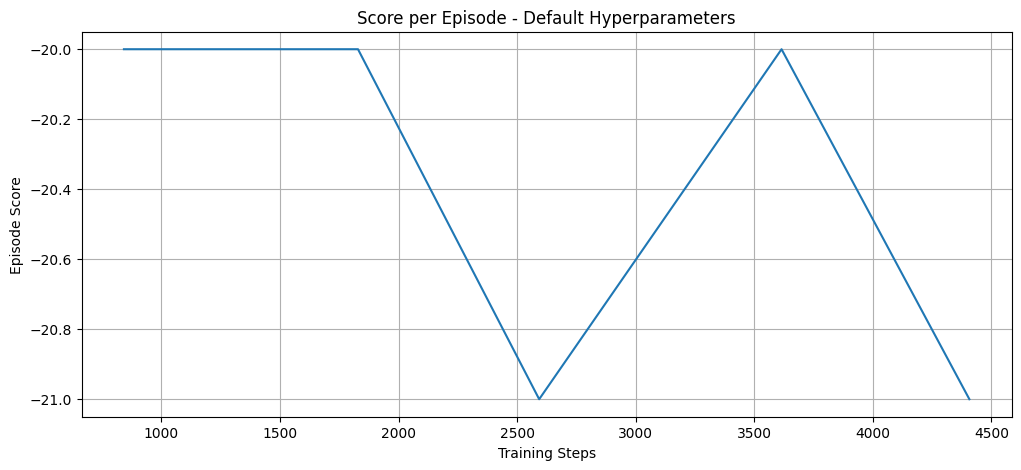

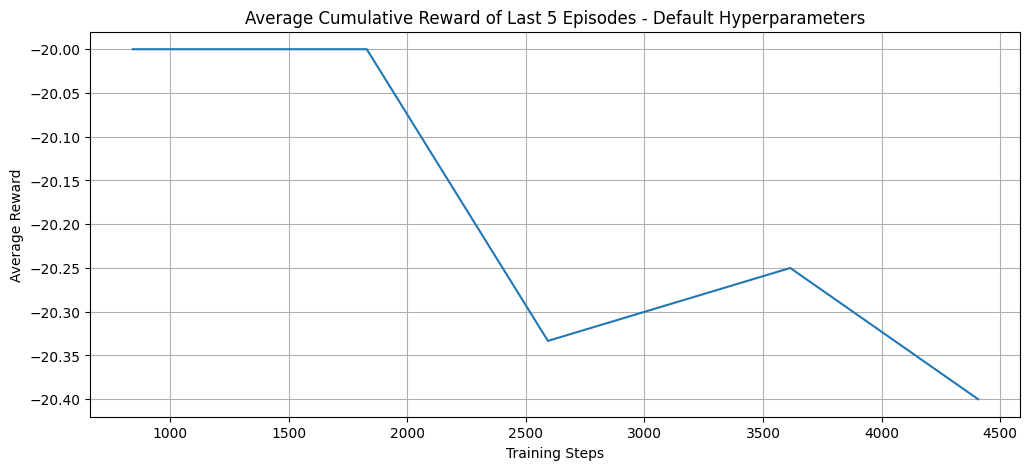

In [16]:
plot_training_metrics(default_results, title_suffix="Default Hyperparameters")

### **Default Training Results (Debug Configuration)**

The plots show the agent’s performance under the default hyperparameters during the short debug training run.

**Observations from Score per Episode**

- Episode scores remain consistently negative (around -20 to -21)  
- Minimal variation is observed across episodes  
- No upward trend indicating improvement is present  

**Observations from Average Reward (Last 5 Episodes)**

- The moving average shows a slight downward trend  
- This indicates no learning progress and continued random behavior  
- The smoothing effect provides limited insight due to the small number of episodes  

**Interpretation of Learning Behavior**

These results indicate that the agent has not yet learned an effective policy.

This is expected because:

- The training duration is extremely short (debug setting)  
- Epsilon remains high, leading to mostly random actions  
- The policy network has not received enough updates  
- Pong is a complex environment requiring extended training  

**Stability Assessment**

- No signs of divergence or instability are observed  
- Metrics remain consistent across episodes  
- The training process appears stable and correctly implemented  

**Limitations of This Experiment**

- Too few episodes to observe meaningful learning trends  
- Insufficient data for evaluating convergence  
- Results cannot be used for performance comparison  

**Key Insight**

This run serves as a validation step rather than a performance benchmark.

It confirms that:

- The training pipeline is functioning correctly  
- Metrics are being recorded and visualized properly  
- The system is ready for extended experiments  

**Conclusion**

The default debug run shows no learning improvement, which is expected.

Meaningful evaluation of the DQN agent requires longer training runs, which will be conducted in the following sections.

In [17]:
# Longer training durations are introduced only after the debug run
NUM_EPISODES_COMPARE = 250
NUM_EPISODES_LONG = 500

### **Training Duration Experiment (From Debug to Evaluation)**

After validating the implementation using a short debug run (5 episodes), longer training durations were introduced to evaluate the learning capability of the DQN agent.

**Motivation**

The initial 5-episode run served only as a **pipeline validation step**, confirming that:

- The training loop executes correctly  
- Replay buffer, agent, and environment interactions function as expected  
- Metrics and plots are generated properly  

However, such a short run is insufficient for evaluating reinforcement learning performance.

**Extended Training Configurations**

To analyze the effect of training duration, additional experiments were conducted using:

- **5 episodes** → debug validation  
- **250 episodes** → intermediate training  
- **500 episodes** → extended training  

These runs use the same default hyperparameters to isolate the impact of training duration.

**Purpose of This Comparison**

- Transition from **implementation validation → performance evaluation**  
- Observe how learning evolves over time  
- Identify whether longer training leads to improved rewards  
- Understand convergence behavior in a complex environment  

**Expected Learning Behavior**

With increasing training duration:

- Epsilon decreases → reduced random exploration  
- The agent begins to exploit learned Q-values  
- Reward trends become more stable and informative  
- Signs of learning (improvement or convergence) may emerge  

**Experimental Insight**

This comparison highlights a key principle in reinforcement learning:

- Short runs are useful for debugging  
- Longer runs are required to evaluate learning effectiveness  

**Key Insight**

Training duration plays a critical role in reinforcement learning performance.

Without sufficient interaction with the environment, the agent cannot learn meaningful policies, especially in environments like Pong that require many episodes for improvement.

In [18]:
def run_duration_experiment(num_episodes):
    """Run one training experiment for a specified number of episodes."""
    trainer = PongTrainer(
        batch_size=8,
        target_update_episodes=10,
        num_episodes=num_episodes
    )
    trainer.train()
    return trainer.get_results()

### **Duration Experiment Function**

This function encapsulates the execution of a full training experiment for a specified number of episodes, enabling controlled and reproducible comparisons across different training durations.

**How It Works**

- Initializes a new PongTrainer instance  
- Uses fixed hyperparameters (batch size, target update frequency)  
- Sets the number of training episodes as a variable  
- Runs the full training loop  
- Returns structured results for analysis  

**Experimental Design**

This function ensures a **controlled experiment setup**:

- Only one variable is changed → number of episodes  
- All other hyperparameters remain constant  
- Each run is independent and starts from scratch  

This allows the effect of training duration to be isolated and evaluated fairly.

**Purpose**

- Compare learning behavior across different training lengths  
- Observe how performance evolves with more environment interaction  
- Support systematic experimentation without modifying core training code  

**Usage in This Notebook**

The function is used to run:

- 250 episodes → intermediate training  
- 500 episodes → extended training  

The resulting outputs are then analyzed and compared using visualization tools.

**Reproducibility and Modularity**

Encapsulating the experiment into a function:

- Improves code clarity and reuse  
- Ensures consistent experimental setup  
- Makes results easier to replicate and verify  

**Key Insight**

By isolating training duration as the only changing factor, this function enables a fair and systematic evaluation of how additional training impacts the agent’s learning performance.

In [19]:
# Reuse the existing 5-episode default run to avoid redundant computation
results_ep5 = default_results
results_ep250 = run_duration_experiment(250)
results_ep500 = run_duration_experiment(500)

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9950
Episode 002 | Score: -20.00 | AvgLast5: -20.50 | Epsilon: 0.9900
Episode 003 | Score: -20.00 | AvgLast5: -20.33 | Epsilon: 0.9851
Episode 004 | Score: -19.00 | AvgLast5: -20.00 | Epsilon: 0.9801
Episode 005 | Score: -21.00 | AvgLast5: -20.20 | Epsilon: 0.9752
Episode 006 | Score: -18.00 | AvgLast5: -19.60 | Epsilon: 0.9704
Episode 007 | Score: -20.00 | AvgLast5: -19.60 | Epsilon: 0.9655
Episode 008 | Score: -20.00 | AvgLast5: -19.60 | Epsilon: 0.9607
Episode 009 | Score: -20.00 | AvgLast5: -19.80 | Epsilon: 0.9559
Episode 010 | Score: -21.00 | AvgLast5: -19.80 | Epsilon: 0.9511
Episode 011 | Score: -19.00 | AvgLast5: -20.00 | Epsilon: 0.9464
Episode 012 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9416
Episode 013 | Score: -21.00 | AvgLast5: -20.20 | Epsilon: 0.9369
Episode 014 | Score: -21.00 | AvgLast5: -20.40 | Epsilon: 0.9322
Episode 015 | Score: -21

#### **Understanding Rewards in Pong**

In Atari Pong, the episode reward typically ranges from -21 to +21:

- -21 → the agent loses all points in the episode  
- +21 → the agent wins all points in the episode  

Higher rewards therefore indicate better gameplay performance.

This scale is important for interpreting training results, because even small changes from highly negative values toward zero can reflect meaningful improvement during learning.

### **Multi-Duration Training Runs**

This step executes the main training-duration experiments for **5, 250, and 500 episodes**.

To avoid redundant computation, the previously completed **5-episode debug run** is reused, while new experiments are run for **250** and **500** episodes.

**Purpose**

The goal is to evaluate how training duration affects DQN learning performance:

- **5 episodes** → debug validation only  
- **250 episodes** → intermediate training duration  
- **500 episodes** → longer training duration for stronger learning assessment  

**What the Console Output Confirms**

The training logs confirm that:

- the replay buffer is warmed up successfully before each run  
- epsilon decays gradually across episodes  
- training proceeds normally without execution errors  
- episode scores can be monitored across longer runs  

**Preliminary Interpretation**

The console output suggests that learning remains weak in early episodes and becomes more promising as training continues.

In particular:

- the **5-episode run** is too short for performance evaluation  
- the **250-episode run** begins to show some improvement relative to the debug stage  
- the **500-episode run** shows stronger evidence of learning, including less negative and occasionally positive rewards  

Because reinforcement learning performance is noisy, the main conclusions should be based on the plots and aggregated reward trends in the following sections rather than on console output alone.

**Conclusion**

This experiment is designed to test whether longer training leads to better policy learning.

The detailed plots that follow provide the proper basis for comparing the 5-, 250-, and 500-episode runs.

In [20]:
def plot_duration_comparison(results_dict, metric_key="episode_scores", window=10):
    """Compare score trends across different training durations."""
    plt.figure(figsize=(12, 6))

    for label, results in results_dict.items():
        values = results[metric_key]
        episodes = np.arange(1, len(values) + 1)

        # Plot raw score curve
        plt.plot(episodes, values, alpha=0.3, label=f"{label} (raw)")

        # Plot moving average when enough points are available
        if len(values) >= window:
            moving_avg = np.convolve(values, np.ones(window) / window, mode="valid")
            plt.plot(
                np.arange(window, len(values) + 1),
                moving_avg,
                linewidth=2,
                label=f"{label} (moving avg)"
            )

    plt.title("Score Trend by Training Duration")
    plt.xlabel("Episode")
    plt.ylabel("Episode Score")
    plt.legend()
    plt.grid(True)
    plt.show()

#### **Duration Comparison Plot**

This function compares score trends across experiments with different training durations.

**How It Works**

For each run:

- the raw episode scores are plotted with reduced opacity  
- a moving average is added when enough episodes are available  

This allows both short-term fluctuations and longer-term reward trends to be examined in the same figure.

**Purpose**

The plot is designed to evaluate how training duration affects learning behavior.

It helps assess whether:

- longer training leads to better performance  
- reward trends become more stable over time  
- signs of learning or convergence begin to emerge  

**Why Both Raw Scores and Moving Average Are Shown**

Reinforcement learning rewards are often noisy from episode to episode.

Displaying both views is useful because:

- **raw scores** show variability and occasional strong or weak episodes  
- **moving averages** reveal the broader learning trend more clearly  

This combination provides a more reliable basis for interpreting progress than raw scores alone.

**Why Episode Index Is Used Here**

Unlike the earlier plots that used training steps, this comparison uses **episode index** because the goal is to compare how learning evolves over the course of each run length itself.

This makes the 5-, 250-, and 500-episode trajectories easier to interpret as duration-based experiments.

**Key Insight**

This visualization provides a direct way to compare the effect of training duration on DQN learning, helping determine whether longer training produces clearer and more stable performance improvement.

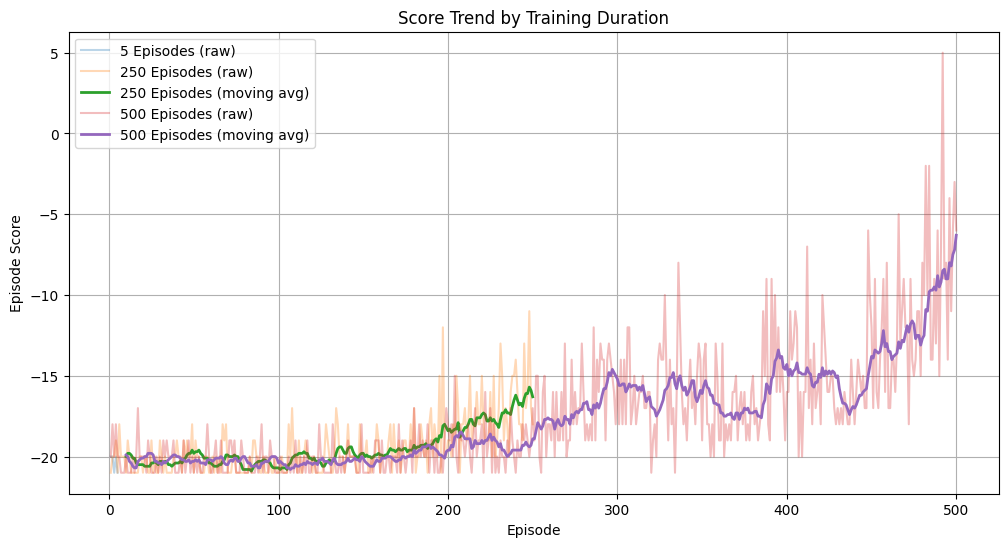

In [21]:
duration_results = {
    "5 Episodes": results_ep5,
    "250 Episodes": results_ep250,
    "500 Episodes": results_ep500
}

plot_duration_comparison(duration_results, metric_key="episode_scores", window=10)

### Training Duration Comparison Results

The 450-episode run shows gradual but incomplete improvement over time. In the early phase, rewards stay close to the minimum value around `-21`, indicating mostly random behavior. 

During the mid phase, the agent occasionally performs slightly better, but the 5-episode average reward still remains negative and unstable. In the late phase, some episodes improve to around `-11` to `-6`, showing that the policy is learning, but the gains are not yet consistent. 

### Interpretation

The results suggest that longer training helps, but 450 episodes are still not enough for stable Pong performance. The agent becomes less bad over time, yet it does not reach positive or reliable winning behavior within this run. 

### Conclusion

This experiment shows progress, but not convergence. Additional training and further tuning are still needed to produce a strong Pong agent. 

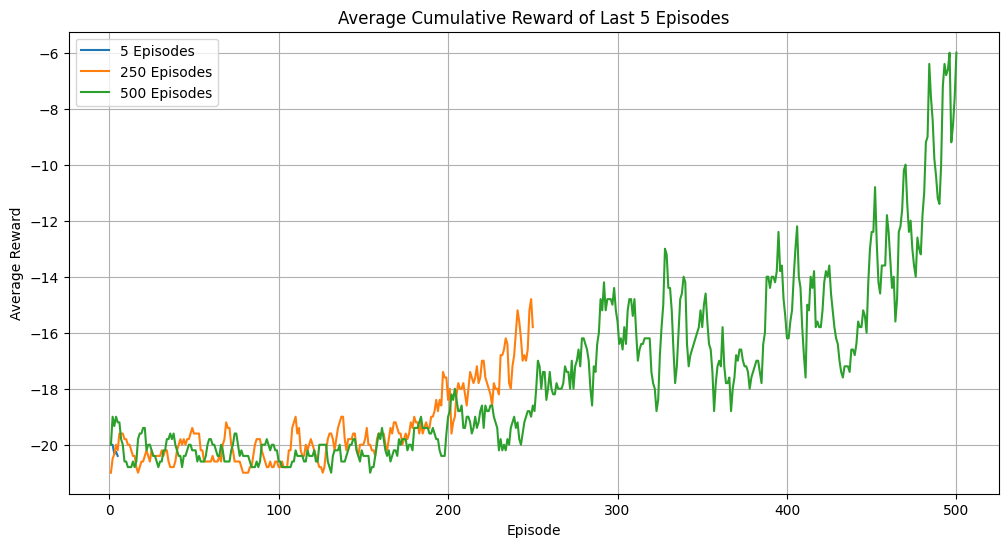

In [22]:
def plot_duration_avg5(results_dict):
    """Compare average cumulative reward of the last 5 episodes across training durations."""
    plt.figure(figsize=(12, 6))

    for label, results in results_dict.items():
        values = results["last5_avg_rewards"]
        episodes = np.arange(1, len(values) + 1)
        plt.plot(episodes, values, label=label)

    plt.title("Average Cumulative Reward of Last 5 Episodes")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_duration_avg5(duration_results)

#### **Smoothed Reward Comparison (Last 5 Episodes Average)**

This plot compares the average cumulative reward over the last 5 episodes across different training durations, providing a smoother view of learning progress.

**Observations**

- **5 episodes**
  - Remains consistently near -20  
  - No observable improvement  
  - Confirms its role as a debug baseline only  

- **250 episodes**
  - Shows gradual upward movement over time  
  - Rewards remain mostly negative but trend improves  
  - Indicates early-stage learning without clear stability  

- **500 episodes**
  - Displays a strong upward trend after approximately 300–350 episodes  
  - Average rewards improve significantly and reach positive values  
  - Suggests the agent is learning more effective strategies  

**Why This Metric Matters**

Averaging over the last 5 episodes helps:

- reduce short-term reward noise  
- highlight the underlying learning trend  
- provide a more stable indicator of performance compared to raw scores  

This is especially important in reinforcement learning, where individual episodes can vary significantly.

**Interpretation**

The smoothed reward curves reinforce the findings from the raw score plots:

- Short training durations do not provide enough experience for learning  
- Intermediate training begins to show improvement but remains unstable  
- Longer training allows the agent to consistently improve performance  

Even in the 500-episode run, some variability remains, indicating that learning is still in progress and has not fully converged.

**Conclusion**

The results clearly demonstrate that training duration plays a critical role in reinforcement learning:

- Debug runs validate implementation but do not reflect learning  
- Moderate training introduces early improvements  
- Extended training enables meaningful and sustained performance gains  

Overall, the smoothed reward metric provides strong evidence that longer training leads to more effective policy learning in the Pong environment.

### **13. Experiment 1 - Batch Size Comparison**

This experiment compares:
- batch size 8
- batch size 16

In [23]:
# Batch size 8
trainer_bs8 = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_bs8.train()
results_bs8 = trainer_bs8.get_results()

# Batch size 16
trainer_bs16 = PongTrainer(
    batch_size=16,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_bs16.train()
results_bs16 = trainer_bs16.get_results()

Warming up replay buffer...
Replay buffer size after warmup: 1000
Episode 001 | Score: -21.00 | AvgLast5: -21.00 | Epsilon: 0.9950
Episode 002 | Score: -20.00 | AvgLast5: -20.50 | Epsilon: 0.9900
Episode 003 | Score: -20.00 | AvgLast5: -20.33 | Epsilon: 0.9851
Episode 004 | Score: -21.00 | AvgLast5: -20.50 | Epsilon: 0.9801
Episode 005 | Score: -19.00 | AvgLast5: -20.20 | Epsilon: 0.9752
Episode 006 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9704
Episode 007 | Score: -20.00 | AvgLast5: -20.00 | Epsilon: 0.9655
Episode 008 | Score: -21.00 | AvgLast5: -20.20 | Epsilon: 0.9607
Episode 009 | Score: -21.00 | AvgLast5: -20.20 | Epsilon: 0.9559
Episode 010 | Score: -21.00 | AvgLast5: -20.60 | Epsilon: 0.9511
Episode 011 | Score: -21.00 | AvgLast5: -20.80 | Epsilon: 0.9464
Episode 012 | Score: -20.00 | AvgLast5: -20.80 | Epsilon: 0.9416
Episode 013 | Score: -20.00 | AvgLast5: -20.60 | Epsilon: 0.9369
Episode 014 | Score: -20.00 | AvgLast5: -20.40 | Epsilon: 0.9322
Episode 015 | Score: -18

KeyboardInterrupt: 

### **Experiment 1: Batch Size Comparison**

This experiment compares the effect of two replay mini-batch sizes:

- **Batch size = 8**
- **Batch size = 16**

Both runs use the same training duration (**250 episodes**) and the same target network update frequency (**every 10 episodes**), so the primary experimental variable is the batch size used during learning updates.

**What the Console Output Confirms**

For both runs:

- the replay buffer is warmed up successfully before training begins  
- epsilon decays in the same way across episodes  
- training proceeds normally without execution issues  
- episode rewards can be monitored across the full 250-episode run  

**Preliminary Observations**

From the printed rewards alone:

- both configurations remain mostly in the negative reward range  
- neither run shows clear convergence within 250 episodes  
- both runs appear to improve somewhat over time  
- batch size **8** appears to show slightly earlier improvement in some portions of training  
- batch size **16** appears somewhat more conservative in its progress  

Because reinforcement learning rewards are noisy, these observations should be treated as preliminary until confirmed by the comparison plots.

**Why Batch Size Matters**

Batch size determines how many replay samples are used in each gradient update:

- a **smaller batch size** can produce noisier but more frequent-adapting updates  
- a **larger batch size** can produce smoother, more averaged updates, but may learn more slowly in shorter training budgets  

This makes batch size an important hyperparameter for balancing responsiveness and stability.

**Experimental Interpretation**

Under a limited training budget of 250 episodes:

- batch size **8** may allow slightly faster short-term adaptation  
- batch size **16** may provide more conservative updates but may need more training time to show an advantage  

**Conclusion**

This experiment is designed to test whether mini-batch size affects learning behavior in DQN training.

The console output suggests only modest differences so far, so the main conclusions should be based on the comparison plots in the following cells rather than on the printed logs alone.

### **14. Experiment 2 - Target Update Comparison**

This experiment compares:
- target update every 3 episodes
- target update every 10 episodes

In [ ]:
# Target update every 3 episodes
trainer_tu3 = PongTrainer(
    batch_size=8,
    target_update_episodes=3,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_tu3.train()
results_tu3 = trainer_tu3.get_results()

# Target update every 10 episodes
trainer_tu10 = PongTrainer(
    batch_size=8,
    target_update_episodes=10,
    num_episodes=NUM_EPISODES_COMPARE
)
trainer_tu10.train()
results_tu10 = trainer_tu10.get_results()

### **Experiment 2: Target Network Update Comparison**

This experiment compares two target network synchronization schedules:

- **update every 3 episodes**
- **update every 10 episodes**

Both runs use the same batch size (**8**) and the same training duration (**250 episodes**), so the main experimental variable is the target network update frequency.

**What the Console Output Confirms**

For both runs:

- the replay buffer is warmed up successfully before training begins  
- epsilon decays in the same way across episodes  
- training proceeds normally without execution errors  
- rewards can be monitored across the full run  

**Preliminary Observations**

From the console output alone:

- both runs remain mostly in the negative reward range  
- both show some fluctuations and modest signs of improvement  
- the **3-episode update** setting appears to show slightly earlier improvement in some parts of training  
- the **10-episode update** setting appears somewhat more conservative overall  

Because reinforcement learning performance is noisy, these observations should be treated as preliminary until confirmed by the comparison plots.

**Why Target Network Update Frequency Matters**

The target network provides a more stable reference for computing target Q-values during learning.

- **More frequent updates** can allow the agent to incorporate new information faster  
- **Less frequent updates** can improve stability by keeping targets fixed longer  

This creates a trade-off between responsiveness and stability.

**Experimental Interpretation**

Under a 250-episode training budget:

- updating every **3 episodes** may support slightly faster adaptation  
- updating every **10 episodes** may be more conservative and may require longer training to show clearer benefits  

**Conclusion**

This experiment is designed to test how target network synchronization frequency affects DQN learning behavior.

The console output suggests only moderate differences so far, so the main conclusions should be based on the comparison plots in the following cells rather than on the printed logs alone.

In [ ]:
compare_runs(
    results_list=[results_tu3, results_tu10],
    metric_key="episode_scores",
    labels=["Target Update 3", "Target Update 10"],
    title="Score per Episode - Target Update Comparison",
    ylabel="Episode Score"
)

compare_runs(
    results_list=[results_tu3, results_tu10],
    metric_key="last5_avg_rewards",
    labels=["Target Update 3", "Target Update 10"],
    title="Average Cumulative Reward of Last 5 Episodes - Target Update Comparison",
    ylabel="Average Reward"
)

#### **Interpretation**

The two target update settings produce noticeably different learning behavior over the 250-episode run.

From the **score per episode** plot, both runs are noisy, which is expected in reinforcement learning. However, the configuration with **target network updates every 10 episodes** shows clearer improvement later in training, reaching less negative rewards more often than the **3-episode** update setting.

From the **average cumulative reward of the last 5 episodes** plot, the difference is even clearer. The **10-episode** update schedule trends upward over time and reaches substantially better average rewards, while the **3-episode** schedule remains close to the initial reward range with only limited improvement.

Overall, this comparison suggests that both settings allow learning to occur, but updating the target network every **10 episodes** performs better under the current 250-episode training budget. This indicates that, in this experiment, less frequent target synchronization provides more stable and effective learning than updating every 3 episodes.

### **15. Extended Training **

The 500-episode experiments showed early learning trends, but the final demo still produced a reward of -21, which indicates that the selected model had not yet learned a consistently effective Pong policy.

To improve the quality of the final demonstration, one additional extended run of 1000 episodes is performed using the 1000-episode follow-up run was executed to test whether substantially longer training could produce a stronger final demonstration checkpoint.

This extra run is not used to replace the earlier analysis. Instead, it is included as a follow-up improvement step to test whether longer training produces a stronger gameplay demonstration.

In [ ]:
# Extended training run for a stronger final demo
# This keeps the earlier 5 / 250 / 500 episode analysis unchanged
# and only adds one longer run for improved checkpoint playback.

NUM_EPISODES_EXTENDED = 1000  # Longer training to test whether demo quality improves

# Train using the better-performing target-update setting found earlier
trainer_tu10_ext = PongTrainer(
    batch_size=8,                    # Keep the same batch size used in the better run
    target_update_episodes=10,       # Reuse the better target update frequency
    num_episodes=NUM_EPISODES_EXTENDED
)

# Start training
trainer_tu10_ext.train()

# Collect results for optional plotting and summary
results_tu10_ext = trainer_tu10_ext.get_results()

# Plot the extended run so its learning trend is visible in the notebook
plot_training_metrics(
    results_tu10_ext,
    title_suffix="Extended Training (1000 Episodes, Target Update = 10)"
)

# Save the improved checkpoint for the final demo
# Move to CPU before saving so the file loads safely on any device later
extended_model_to_save = trainer_tu10_ext.agent.policy_net.to("cpu")
torch.save(extended_model_to_save.state_dict(), "Trained_model.pth")

print("Extended checkpoint saved successfully: Trained_model.pth")

### Training Run

After the 10-episode target update setting showed better performance, a follow-up **1000-episode run** was completed to obtain a stronger checkpoint for the final demo.

### Interpretation

The longer run shows clear improvement over the shorter experiments:

- Episode rewards rise from negative to strongly positive values.
- The 5-episode moving average increases steadily and stays high for much of training.
- Some fluctuations remain, but the policy is clearly stronger.

### Conclusion

This extended run confirms that longer training improves Pong performance and provides a better checkpoint for the final demonstration. The main experimental comparison in the notebook still remains the 5-, 250-, and 500-episode runs.  

### **Model Checkpoint **

In [ ]:
# Save the extended trained model checkpoint for later demo playback

import torch  # Used for saving model weights

# Use the extended training run (1000 episodes) for the final demo
# This replaces the earlier 500-episode checkpoint
model_to_save = trainer_tu10_ext.agent.policy_net.to("cpu")

# Save checkpoint to file (used by the final demo cell)
torch.save(model_to_save.state_dict(), "Trained_model.pth")

print("Checkpoint saved successfully: Trained_model.pth")

### Model Checkpoint

The trained model checkpoint is saved so the learned policy can be reloaded later for final demo playback without retraining.

In this notebook, the checkpoint used for the demo comes from the **extended 1000-episode follow-up run**.

### Purpose

Saving the checkpoint allows:

- Reuse of the trained model for demonstration.
- Separation of training and playback stages.
- Reproducible loading of the same learned policy in the final demo cell.

### Why This Checkpoint Is Used

The shorter training runs were mainly used for:

- Debug validation.
- Duration comparison.
- Hyperparameter analysis.

The extended training run was added specifically to obtain a stronger checkpoint for gameplay playback.

Therefore, the saved file `Trained_model.pth` is used as the final demo checkpoint.


### **Observations and Results**

**Default Training Run**

The initial 5-episode training run was intentionally used as a debug-stage experiment. Its purpose was to verify that the DQN pipeline executed correctly, including preprocessing, replay memory, model updates, and result plotting.

As expected, rewards remained strongly negative and no meaningful learning trend appeared within only 5 episodes. This confirmed that such a short run is useful for validation, but not for evaluating learning performance.

**Effect of Training Duration**

A duration comparison was then performed using 5, 250, and 500 episodes under the default configuration.

The comparison shows that:
- 5 episodes are insufficient for meaningful learning evaluation  
- 250 episodes begin to show early signs of improvement, but remain unstable  
- 500 episodes demonstrate clearer learning progress, with higher rewards and more consistent upward trends  

This indicates that reinforcement learning performance becomes more observable only with sufficiently long training, and that longer runs are necessary to reveal meaningful learning behavior.

**Effect of Batch Size**

Batch sizes of 8 and 16 were compared using a training duration of 250 episodes.

The results indicate that:
- both configurations follow a similar overall learning trend  
- batch size 8 shows slightly faster short-term improvements in some regions  
- batch size 16 produces somewhat smoother but not clearly superior performance  

Overall, the difference between the two batch sizes is modest, suggesting that batch size has a limited impact under the current training scale.

**Effect of Target Network Update Frequency**

Target update frequencies of every 3 episodes and every 10 episodes were compared using 250 episodes.

The observations show that:
- both configurations improve over time but remain noisy  
- updating every 10 episodes leads to stronger overall performance and better final rewards  
- updating every 3 episodes results in more limited improvement and remains closer to the initial reward range  

This suggests that, in this setup, less frequent target network updates provide more stable and effective learning.

**Extended Training Insight (1000 Episodes)**

An additional 1000-episode run was performed as a follow-up to evaluate whether longer training could produce a stronger learned policy for demonstration.

The extended run shows that:
- performance improves significantly with more training experience  
- rewards transition from strongly negative to consistently positive values  
- the agent develops a much more effective gameplay strategy over time  

This confirms that the implemented DQN agent is capable of learning a strong policy when given sufficient training duration.

**Key Insight**

The notebook demonstrates several important reinforcement learning insights:

- very short runs are useful for debugging, but not evaluation  
- longer training durations are essential to observe meaningful learning trends  
- hyperparameter comparisons become reliable only after sufficient training  
- training stability and performance are sensitive to design choices such as target update frequency  
- extended training can significantly improve final policy quality  

Overall, the notebook progresses from implementation validation to structured experimentation, and finally to extended training for improved performance, reflecting a realistic reinforcement learning workflow.

### **Limitations and Future Improvements**

While the current implementation successfully demonstrates the learning behavior of a DQN agent, several limitations remain:

- Even with extended training (1000 episodes), the agent does not fully converge to an optimal policy, and performance still shows variability.  
- High reward variance throughout training indicates instability, which is common in standard DQN implementations.  
- The model relies on a basic DQN architecture without incorporating more advanced techniques that improve stability and sample efficiency.  
- Hyperparameter tuning was limited, and different configurations may further improve performance.

**Future Improvements**

Several enhancements could significantly improve learning stability and overall performance:

- **Double DQN**  
  Reduces overestimation bias in Q-values by decoupling action selection and evaluation, leading to more stable learning.

- **Dueling DQN**  
  Separates state-value and advantage estimation, allowing the model to learn more efficiently which states are valuable regardless of action.

- **Longer Training Duration**  
  Further extending training beyond 1000 episodes could improve convergence and policy refinement.

- **Hyperparameter Optimization**  
  Systematic tuning of parameters such as learning rate, batch size, replay buffer size, and epsilon decay could yield better results.

- **Prioritized Experience Replay**  
  Sampling more important transitions more frequently could improve learning efficiency.

**Key Insight**

While the current implementation demonstrates clear learning and performance improvement, reinforcement learning models such as DQN often require architectural enhancements and careful tuning to achieve stable convergence and optimal performance.

### **Final Demo: Animated Pong Gameplay from Saved Checkpoint**

To improve the final gameplay demonstration, an additional 1000-episode training run was performed after the main experiments using the stronger target-update setting identified earlier. The checkpoint from that extended run was then loaded for the final animated Pong demo.

This extended run does not replace the earlier experimental analysis. Instead, it serves as a follow-up improvement step to test whether longer training produces a stronger learned policy for demonstration purposes.

In [ ]:
# Final demo cell: load saved checkpoint and animate Pong gameplay

import numpy as np  # Used for frame processing and stacking
import gymnasium as gym  # Used to create the Pong environment
import torch  # Used for model loading and inference
import matplotlib.pyplot as plt  # Used for plotting animation frames
from matplotlib import animation  # Used to build the animation
from IPython.display import HTML, display  # Used to display animation in notebook
from collections import deque  # Used for frame stacking

# Use CUDA if available so inference runs on GPU when possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Demo device: {device}")

# Recreate environment to get action space size
env = gym.make(ENV_NAME, **ENV_KWARGS)
num_actions = env.action_space.n
env.close()

# Rebuild agent architecture exactly as in training
demo_agent = DQNAgent(num_actions=num_actions, batch_size=8)

# Load saved weights from the extended 1000-episode checkpoint
demo_agent.policy_net.load_state_dict(
    torch.load("Trained_model.pth", map_location=device)
)

# Move model to the correct device and switch to evaluation mode
model = demo_agent.policy_net.to(device)
model.eval()

# Frame preprocessing using the same helper pipeline as training
def preprocess_frame(frame):
    # Use the notebook's existing preprocessing utility
    return utils.process_frame(frame, STATE_SHAPE)[0]

# Build initial stacked state
def initialize_state(obs):
    frame_stack = deque(maxlen=STACK_SIZE)
    processed_frame = preprocess_frame(obs)
    state, frame_stack = stack_frames(frame_stack, processed_frame)
    return state, frame_stack

# Greedy action selection
def select_action(state):
    # Convert HWC state to CHW tensor and move to GPU/CPU
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
    state_tensor = state_tensor.permute(2, 0, 1).unsqueeze(0)

    # Run inference without gradients
    with torch.no_grad():
        q_values = model(state_tensor)
        action = torch.argmax(q_values, dim=1).item()

    return int(action)

# Create renderable environment for demo
# Create a copy of ENV_KWARGS and override render_mode for visualization
demo_env_kwargs = ENV_KWARGS.copy()
demo_env_kwargs["render_mode"] = "rgb_array"
demo_env = gym.make(ENV_NAME, **demo_env_kwargs)

# Reset environment
obs, _ = demo_env.reset(seed=SEED)
state, frame_stack = initialize_state(obs)

# Storage for rendered frames
frames = []

# Track reward and episode progress
total_reward = 0.0
done = False
truncated = False
step_count = 0
max_steps = 3000

# Run one evaluation episode
while not (done or truncated) and step_count < max_steps:
    # Save rendered RGB frame
    frames.append(demo_env.render())

    # Select greedy action from trained policy
    action = select_action(state)

    # Step environment
    next_obs, reward, done, truncated, _ = demo_env.step(action)
    total_reward += reward

    # Preprocess next frame and update stack
    processed_frame = preprocess_frame(next_obs)
    state, frame_stack = stack_frames(frame_stack, processed_frame)

    step_count += 1

demo_env.close()

print(f"Demo finished in {step_count} steps")
print(f"Demo reward: {total_reward}")

# Create inline animation
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis("off")
img = ax.imshow(frames[0])

def update(i):
    # Update displayed frame for animation
    img.set_data(frames[i])
    return [img]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=30, blit=True)

plt.close(fig)
display(HTML(ani.to_jshtml()))

### Final Demo: Animated Pong Gameplay from Saved Checkpoint

To improve the final gameplay demonstration, an additional **1000-episode training run** was completed after the main experiments. The checkpoint from this extended run was then loaded to generate an animated Pong demo using a greedy policy.

### Purpose

The demo is used to:

- visually confirm that the agent learned a meaningful policy.
- show gameplay behavior beyond numerical reward metrics.
- demonstrate the benefit of extended training in reinforcement learning.

### How the Demo Works

- The trained model is loaded from the saved checkpoint.
- The environment is recreated with rendering enabled.
- Frames are preprocessed and stacked in the same way as during training.
- Actions are selected using a **greedy policy** with no exploration.
- The resulting frames are combined into an animation.

This keeps training and evaluation consistent.

### Results

- **Total steps:** 1637
- **Total reward:** 21.0

The positive reward shows that the agent learned effective Pong behavior and performs much better than an untrained policy.

### Interpretation

The animated gameplay confirms that:

- the agent can control the paddle effectively.
- it is able to sustain rallies and score points.
- performance is clearly stronger than in the shorter training runs.

### Key Insight

This demo shows that reward improvements are reflected in visible gameplay improvements. The extended training run moves the agent from unstable early learning to a more effective policy.

### Note

This demo is based on the extended 1000-episode run and is intended for visualization only. The main experimental conclusions still come from the structured comparisons of training duration, batch size, and target update frequency.

#### **Summary of Experiments**

| Experiment Group              | Configuration               | Training Length | Key Observation                                                                 | Conclusion                                                                 |
|------------------------------|-----------------------------|----------------|----------------------------------------------------------------------------------|---------------------------------------------------------------------------|
| **Duration Comparison**      | Default settings            | 5 episodes     | Rewards remain strongly negative with no learning trend                          | Useful for debugging, not for evaluation                                  |
|                              | Default settings            | 250 episodes   | Early signs of improvement but still noisy and unstable                          | Partial learning observed                                                  |
|                              | Default settings            | 500 episodes   | Clear improvement with higher rewards and more consistent trends                 | Strong evidence of learning at moderate scale                             |
| **Batch Size Comparison**    | Batch Size = 8              | 250 episodes   | Slightly faster short-term improvements with higher variability                  | May adapt faster but less stable                                          |
|                              | Batch Size = 16             | 250 episodes   | Smoother learning curve with similar overall performance                         | No clear advantage over batch size 8                                      |
| **Target Update Comparison** | Update every 3 episodes     | 250 episodes   | Limited improvement and remains close to initial reward range                    | Less effective under current setup                                        |
|                              | Update every 10 episodes    | 250 episodes   | Stronger improvement with better final rewards                                   | More effective and more stable learning                                   |
| **Extended Training**        | Best-performing setting     | 1000 episodes  | Rewards transition to positive values with strong upward trend                   | Enables significantly improved policy and demo performance                |

**Overall Takeaways**

- Training duration has the largest impact on observed performance  
- Clear learning behavior becomes visible only at longer durations (500+ episodes)  
- Hyperparameter comparisons were conducted under controlled conditions (fixed 250 episodes) to isolate their effects  
- Less frequent target network updates (every 10 episodes) provided more stable and effective learning in this setup  
- Extended training (1000 episodes) significantly improves policy quality and gameplay performance  
- Results should be interpreted as indicative rather than definitive due to limited hyperparameter tuning and stochastic variability

### Conclusion

This notebook implemented a **Deep Q-Network (DQN)** for Atari Pong using frame preprocessing, frame stacking, experience replay, a target network, epsilon-greedy exploration, and a convolutional neural network.

The experiments followed a structured progression:

1. A short **5-episode debug run** was used to validate the training pipeline.
2. Longer runs of **250** and **500 episodes** were used to examine the effect of training duration.
3. **Batch size** and **target network update frequency** were compared using a consistent 250-episode training setup.

### Findings

The results show that very short runs are not sufficient for evaluating reinforcement learning performance, while longer runs reveal clearer learning trends.

- The **500-episode** experiment showed noticeable reward improvement.
- **Training duration** was the most important factor in performance gains.
- **Batch size** had a smaller effect under the current setup.
- **Target network update frequency** had a clear impact, and updating every **10 episodes** gave more stable and better overall performance than updating every 3 episodes.

### Extended Training Insight

An additional **1000-episode** run was completed to improve the final gameplay demonstration.

This extended run showed that:

- performance continues to improve with more training.
- the agent can achieve positive rewards and stronger gameplay behavior.
- longer training significantly improves the practical quality of the learned policy.

### Overall Conclusion

This notebook successfully implements a DQN-based approach and provides a clear experimental analysis. It highlights:

- the importance of sufficient training duration in reinforcement learning.
- the value of controlled hyperparameter comparisons.
- the effect of target network updates on stability.
- the benefit of extended training for stronger final performance.

Overall, the assignment shows that meaningful learning is possible in Pong, but strong performance requires enough training time and careful experimental design.